In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Marvel Movies.csv to Marvel Movies.csv


What Marvel categories deliver the highest ROI?

category
Deadpool           9.322727
Spider-Man         6.111786
Avengers           5.093604
Black Panther      4.050000
Dr Strange         3.428485
Iron Man           3.291034
Guardians          3.084804
Captain America    2.815619
Thor               2.747222
Ant-Man            2.560308
Unique             1.862617
Name: roi, dtype: float64


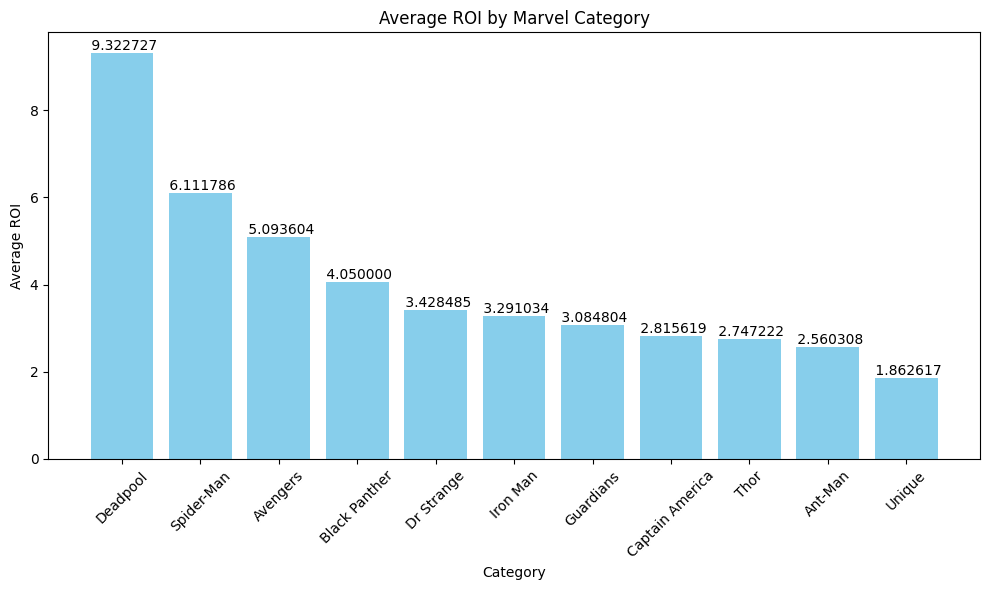

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.read_csv('Marvel Movies.csv')
df = pd.read_csv('Marvel Movies.csv')

df['worlwide gross'] = pd.to_numeric(df['worldwide gross'], errors='coerce')
df['budget'] =pd.to_numeric(df['budget'], errors='coerce')
df['roi'] = (df['worlwide gross'] - df['budget']) / df['budget']

roi_by_category =(
    df.groupby('category')['roi']
    .mean()
    .sort_values(ascending=False)
)
print(roi_by_category)

plt.figure(figsize=(10, 6))
bars = plt.bar(roi_by_category.index, roi_by_category.values, color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height: 2f}",
        ha='center',
        va='bottom'
    )

plt.title("Average ROI by Marvel Category")
plt.xlabel("Category")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which films rely on opening weekend results vs long tail performances?

<Figure size 1400x800 with 0 Axes>

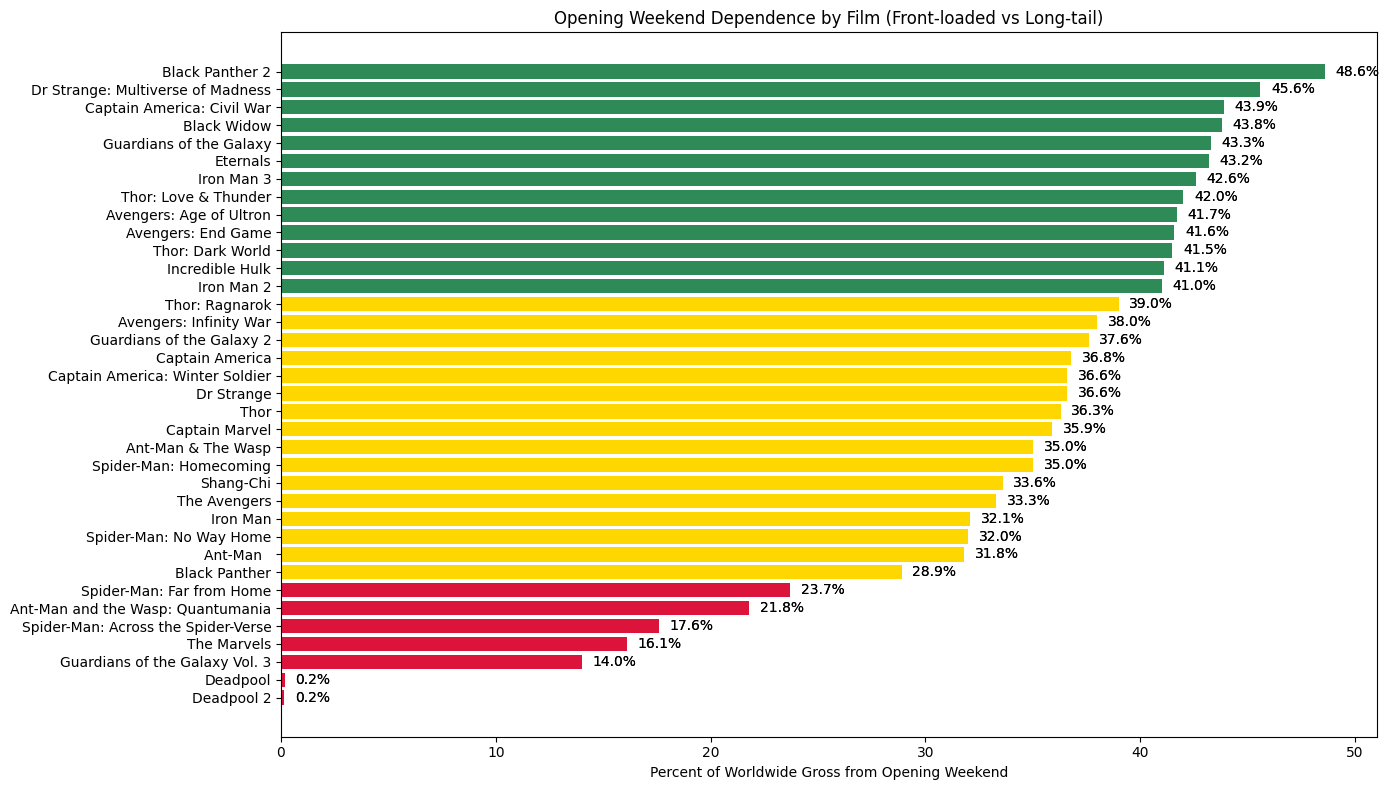

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Marvel Movies.csv")

# Convert the % column to numeric (remove % signs if present)
df['% gross from opening weekend'] = (
    df['% gross from opening weekend']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

df_sorted = df.sort_values('% gross from opening weekend', ascending=False)
def classify(p):
    if p >= 40:
        return "Front-loaded"
    elif p >= 25:
        return "Balanced"
    else:
        return "Long-tail"



df_sorted['performance_type'] = df_sorted['% gross from opening weekend'].apply(classify)

plt.figure(figsize=(14, 8))

plt.figure(figsize=(14, 8))
plt.barh(df_sorted['movie'], df_sorted['% gross from opening weekend'], color=colors)
plt.xlabel("Percent of Worldwide Gross from Opening Weekend")
plt.title("Opening Weekend Dependence by Film (Front-loaded vs Long-tail)")
plt.gca().invert_yaxis()

for index, value in enumerate(df_sorted['% gross from opening weekend']):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center')

# Add labels to bars
for index, value in enumerate(df_sorted['% gross from opening weekend']):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center')

color_map = {
    "Front-loaded": "seagreen",
    "Balanced": "gold",
    "Long-tail": "crimson"
}

colors = df_sorted['performance_type'].map(color_map)

plt.tight_layout()
plt.show()

Opening weekend % vs critics/audience scores. Do films with low opening weekend % have better critc scores/audience reception?

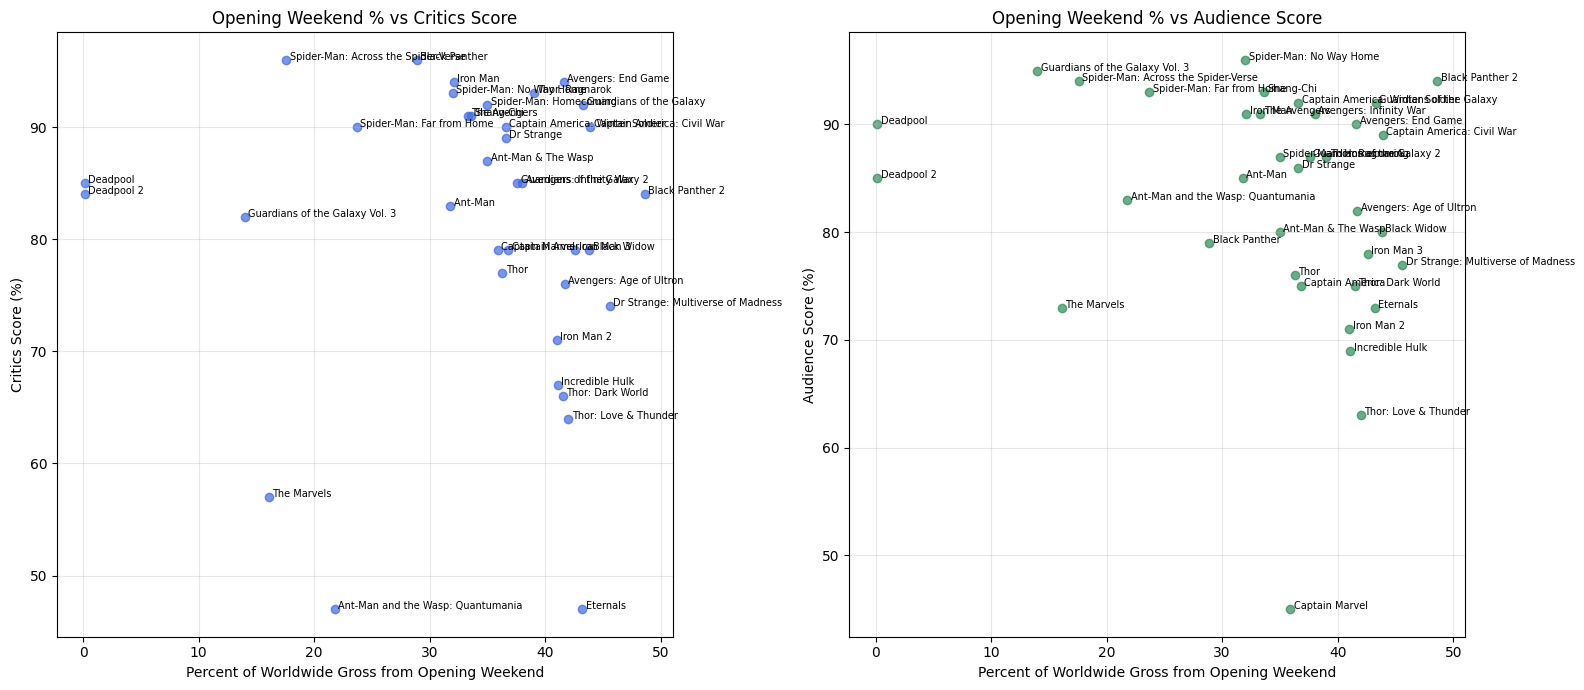

Correlation (Opening Weekend % vs Critics Score): -0.059
Correlation (Opening Weekend % vs Audience Score): -0.226


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Marvel Movies.csv")

# Clean numeric columns
df['% gross from opening weekend'] = (
    df['% gross from opening weekend']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

df['critics % score'] = (
    df['critics % score']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

df['audience % score'] = (
    df['audience % score']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

# ---------------------------------------------------------
# Create side-by-side subplots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# ---------------- Left Plot: Critics ---------------------
axes[0].scatter(
    df['% gross from opening weekend'],
    df['critics % score'],
    color='royalblue',
    alpha=0.7
)

for _, row in df.iterrows():
    axes[0].text(
        row['% gross from opening weekend'] + 0.3,
        row['critics % score'],
        row['movie'],
        fontsize=7
    )

axes[0].set_title("Opening Weekend % vs Critics Score")
axes[0].set_xlabel("Percent of Worldwide Gross from Opening Weekend")
axes[0].set_ylabel("Critics Score (%)")
axes[0].grid(alpha=0.3)

# ---------------- Right Plot: Audience --------------------
axes[1].scatter(
    df['% gross from opening weekend'],
    df['audience % score'],
    color='seagreen',
    alpha=0.7
)

for _, row in df.iterrows():
    axes[1].text(
        row['% gross from opening weekend'] + 0.3,
        row['audience % score'],
        row['movie'],
        fontsize=7
    )

axes[1].set_title("Opening Weekend % vs Audience Score")
axes[1].set_xlabel("Percent of Worldwide Gross from Opening Weekend")
axes[1].set_ylabel("Audience Score (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr_critics = df['% gross from opening weekend'].corr(df['critics % score'])
corr_audience = df['% gross from opening weekend'].corr(df['audience % score'])

print("Correlation (Opening Weekend % vs Critics Score):", round(corr_critics, 3))
print("Correlation (Opening Weekend % vs Audience Score):", round(corr_audience, 3))